In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pyflct

# Tutorial

In [ ]:
image1 = np.zeros((10, 10))
image1[0:3, 0:3] = 1

image2 = np.zeros((10, 10))
image2[0:3, 1:4] = 1

In [ ]:
vel_x, vel_y, vm = pyflct.flct(image1, image2, 1, 1, 2.3)

In [ ]:
# But first we need to create a meshgrid on which the flow field will be plotted
X = np.arange(0, 10, 1)
Y = np.arange(0, 10, 1)
U, V = np.meshgrid(X, Y)

# Plotting the first image
fig = plt.figure(figsize=(12, 4))

ax1 = fig.add_subplot(131)
plt.imshow(image1, origin="lower")
ax1.set_title("First Image")

# Plot the 2D flow field
ax2 = fig.add_subplot(132)
ax2.quiver(U, V, vel_x, vel_y, scale=20)
ax2.set_title("Flow Field")

# Plot the shifted image
ax3 = fig.add_subplot(133)
plt.imshow(image2, origin="lower")
ax3.set_title("Second Image")

In [ ]:
# Creating the input arrays
image1 = np.zeros((10, 10))
image1[0:3, 0:3] = 1

image2 = np.zeros((10, 10))
image2[1:4, 0:3] = 1

In [ ]:
vel_x, vel_y, vm = pyflct.flct(image1, image2, 1, 1, 2.3)

In [ ]:
# Plotting the first image
fig = plt.figure(figsize=(12, 4))

ax1 = fig.add_subplot(131)
plt.imshow(image1, origin="lower")
ax1.set_title("First Image")

# Plot the 2D flow field
ax2 = fig.add_subplot(132)
ax2.quiver(U, V, vel_x, vel_y, scale=20)
ax2.set_title("Flow Field")

# Plot the shifted image
ax3 = fig.add_subplot(133)
plt.imshow(image2, origin="lower")
ax3.set_title("Second Image")

In [ ]:
# Creating the input arrays
image1 = np.zeros((10, 10))
image1[0:3, 0:3] = 1

image2 = np.zeros((10, 10))
image2[1:4, 1:4] = 1

vel_x, vel_y, vm = pyflct.flct(image1, image2, 1, 1, 2.3)

In [ ]:
# Plotting the first image
fig = plt.figure(figsize=(12, 4))

ax1 = fig.add_subplot(131)
plt.imshow(image1, origin="lower")
ax1.set_title("First Image")

# Plot the 2D flow field
ax2 = fig.add_subplot(132)
ax2.quiver(U, V, vel_x, vel_y, scale=20)
ax2.set_title("Flow Field")

# Plot the shifted image
ax3 = fig.add_subplot(133)
plt.imshow(image2, origin="lower")
ax3.set_title("Second Image")

# 3/27 HST

In [210]:
import cv2
from pathlib import Path
from scipy.ndimage import uniform_filter, median_filter
from itertools import pairwise
from tqdm.auto import tqdm
from flct import extract_frame, get_vels, display

vidfn = '/Users/michaellavender/Documents/BUSPC/optical flow/HST-7196-20130327-01-copy.mp4'

In [4]:
t1 = 3*60 + 33
t2 = 3*60 + 41
i1 = t1 * 15
i2 = t2 * 15

out_dir = Path('/Users/michaellavender/Documents/BUSPC/optical flow/flct/frames')

for i in range(i1, i2, 2):
    outfn = out_dir / f'frame{i}.png'
    extract_frame(vidfn, i, outfn)

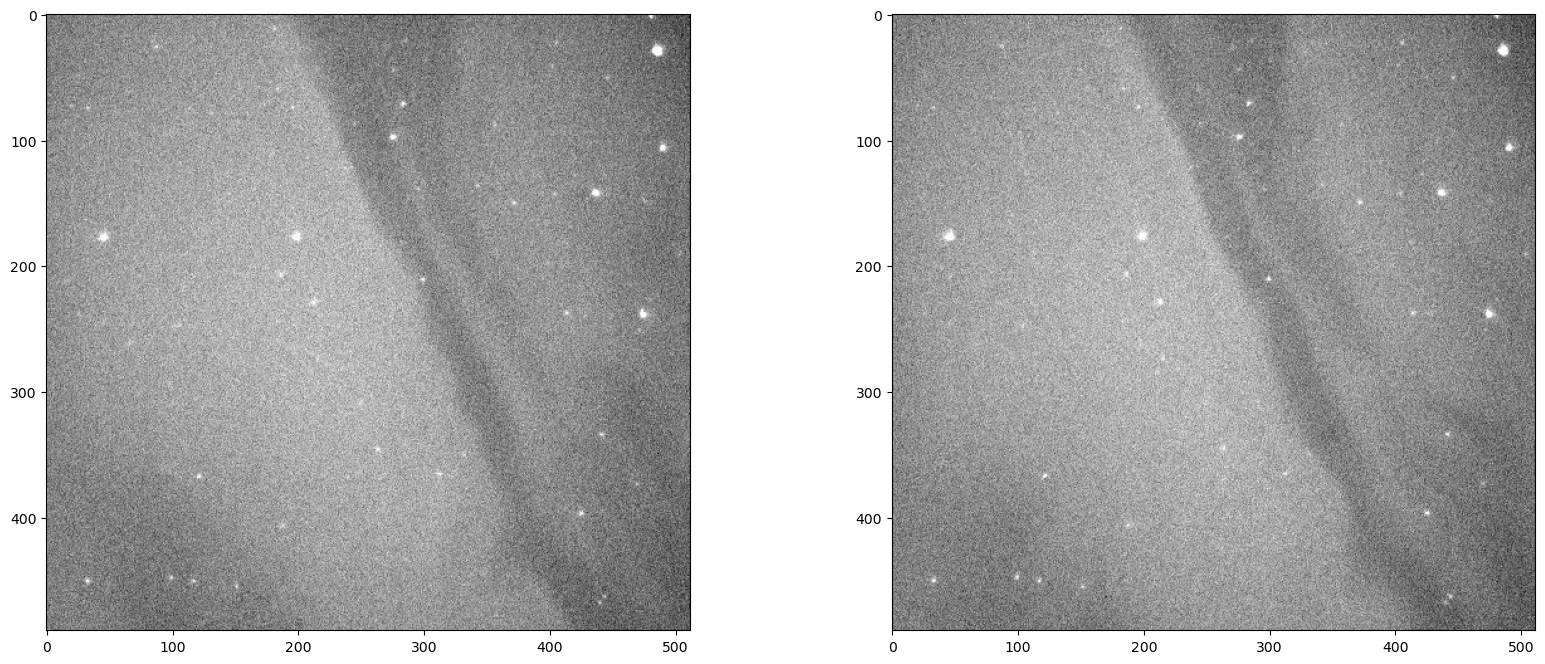

In [5]:
f1 = cv2.imread('/Users/michaellavender/Documents/BUSPC/optical flow/flct/frames/frame3247.png')
f1 = cv2.cvtColor(f1, cv2.COLOR_BGR2GRAY)
f1 = f1[0:490, :]

f2 = cv2.imread('/Users/michaellavender/Documents/BUSPC/optical flow/flct/frames/frame3249.png')
f2 = cv2.cvtColor(f2, cv2.COLOR_BGR2GRAY)
f2 = f2[0:490, :]


fig, axes = plt.subplots(1, 2, figsize=(20, 8))
axes[0].imshow(f1, 'gray')
axes[1].imshow(f2, 'gray')

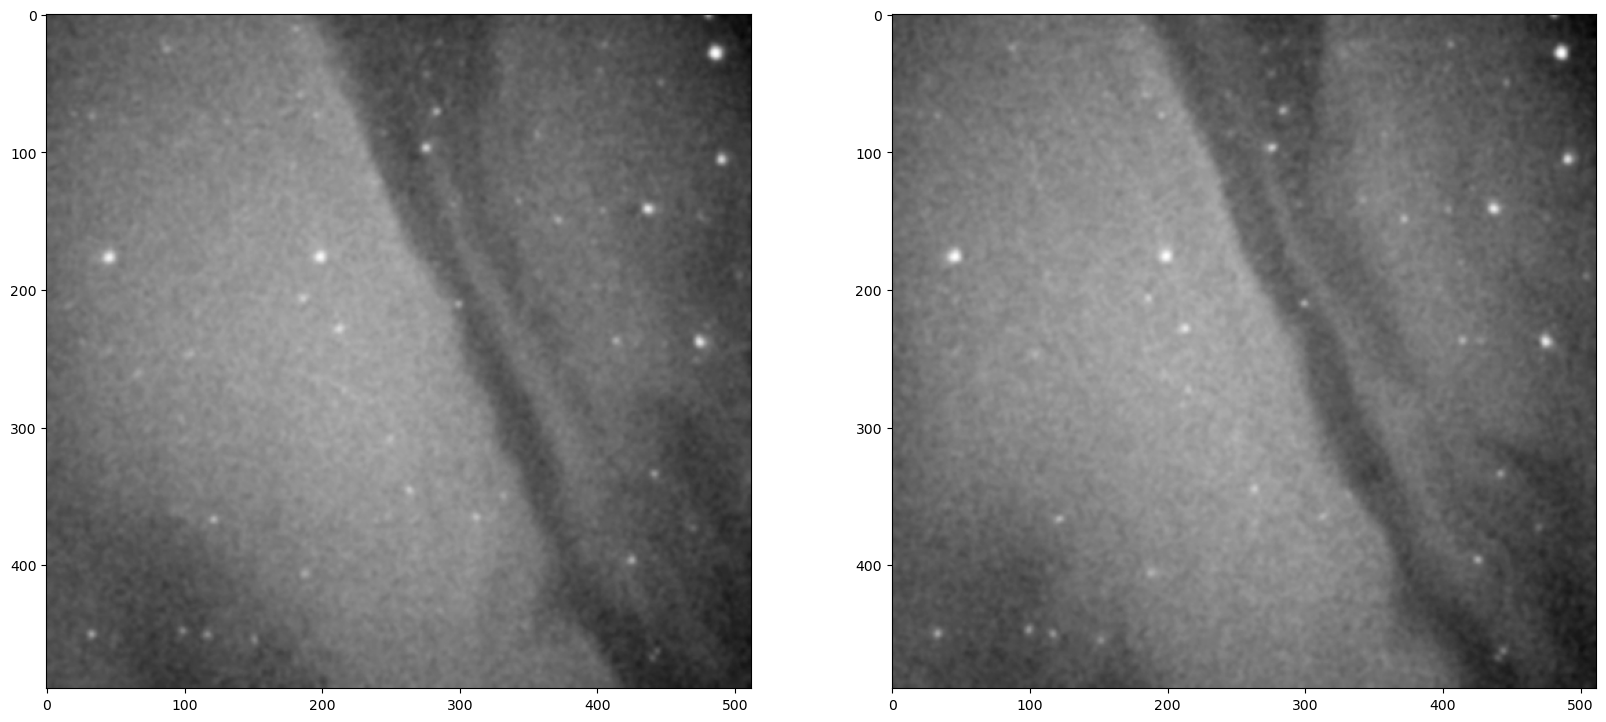

In [6]:
size = 9
sigma = 0

f1_blur = cv2.GaussianBlur(f1, (size, size), sigma)
f2_blur = cv2.GaussianBlur(f2, (size, size), sigma)

fig, axes = plt.subplots(1, 2, figsize=(20, 10))
axes[0].imshow(f1_blur, 'gray')
axes[1].imshow(f2_blur, 'gray')

flct: nominal sliding box size = 4
flct: relative threshold in abs. units = 187.5
flct: mean value of gamma^2/sigma^2 = 0.906567

flct: finished


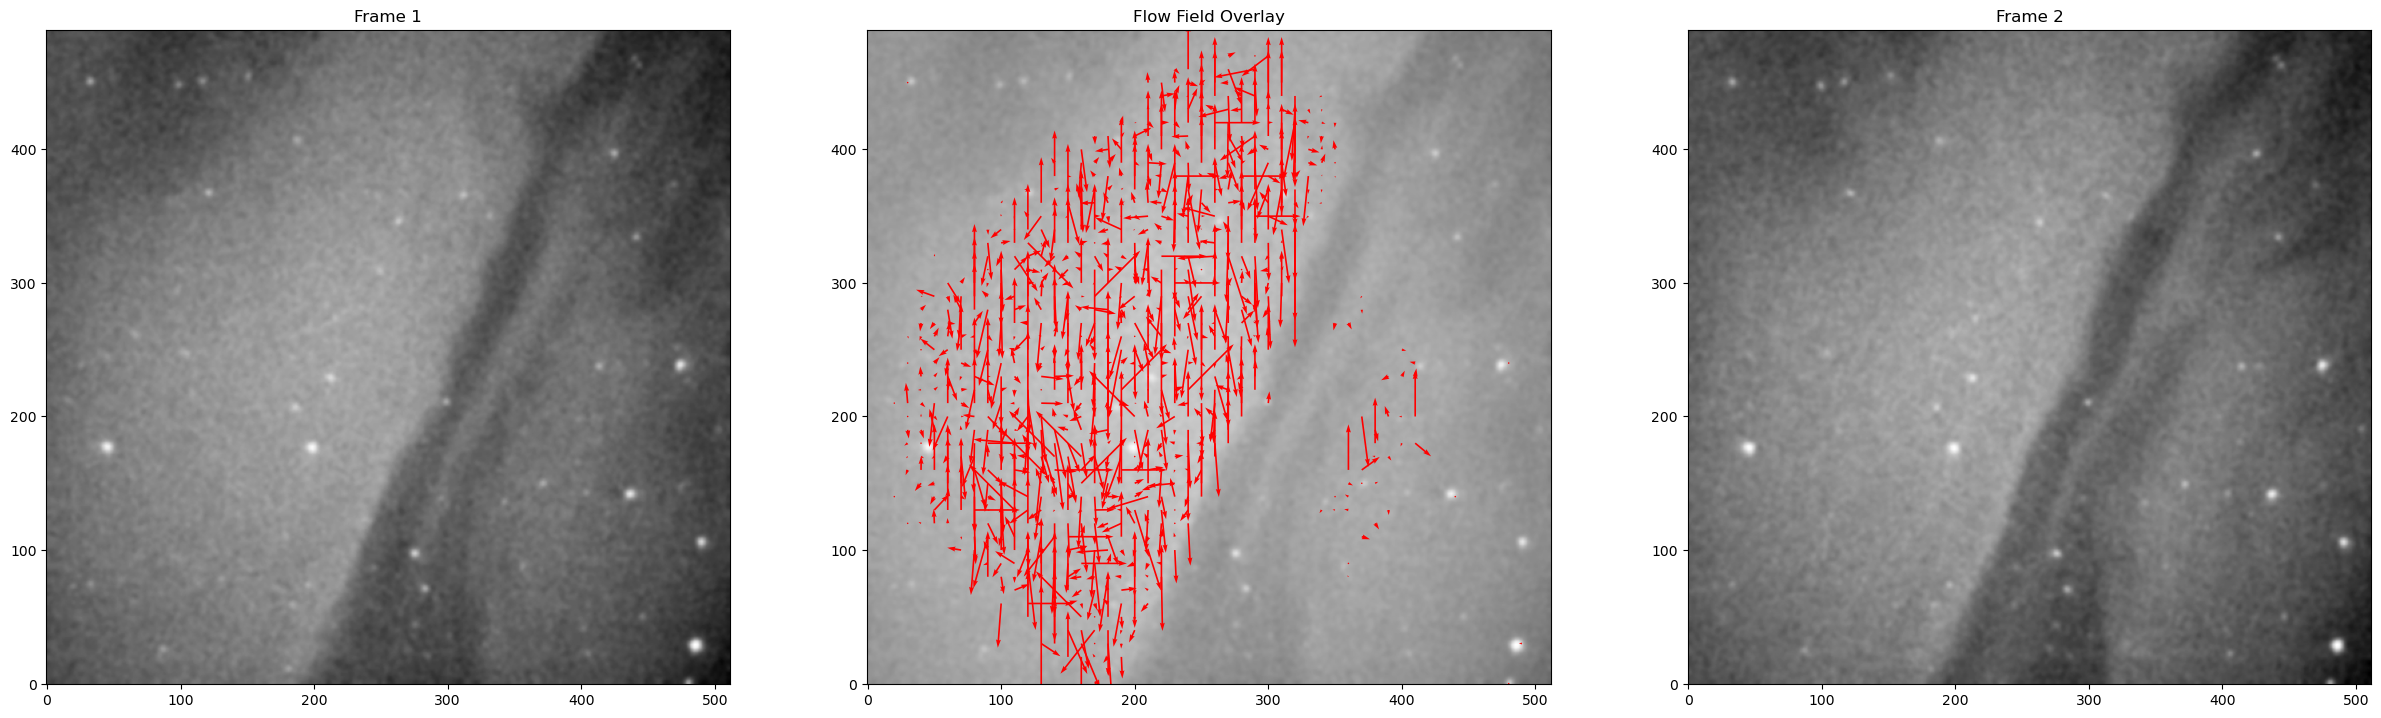

In [32]:
# 1. Run FLCT optical flow
vel_x, vel_y, vm = pyflct.flct(f1_blur, f2_blur, deltat=30, deltas=40, sigma=1, thresh=0.75)

vel_x_masked = np.where(vm, vel_x, np.nan)
vel_y_masked = np.where(vm, vel_y, np.nan)

# 2. Extract dimensions dynamically from your image shape (height, width)
height, width = f1_blur.shape 

# 3. Create the meshgrid correctly mapping X to width and Y to height
X = np.arange(0, width, 1)
Y = np.arange(0, height, 1)
U, V = np.meshgrid(X, Y)

step = 10

# 5. Subsample coordinates and velocities uniformly
U_sub = U[::step, ::step]
V_sub = V[::step, ::step]
vel_x_sub = vel_x_masked[::step, ::step]
vel_y_sub = vel_y_masked[::step, ::step]

# 6. Plotting
fig = plt.figure(figsize=(30, 10))

# Plotting the first image
ax1 = fig.add_subplot(131)
ax1.imshow(f1_blur, cmap='gray', origin="lower")
ax1.set_title("Frame 1")

# Plot vectors over the background frame to check structural alignment
ax2 = fig.add_subplot(132)
ax2.imshow(f1_blur, cmap='gray', origin="lower", alpha=0.6) # Added background for context
ax2.quiver(U_sub, V_sub, vel_x_sub, vel_y_sub, scale=20, color='red') # Changed color for visibility
# ax2.quiver(U, V, vel_x, vel_y, scale=100, color='red') # Changed color for visibility
ax2.set_title("Flow Field Overlay")

# Plot the shifted image
ax3 = fig.add_subplot(133)
ax3.imshow(f2_blur, cmap='gray', origin="lower")
ax3.set_title("Frame 2")

plt.show()

flct: nominal sliding box size = 32
flct: relative threshold in abs. units = 175
flct: mean value of gamma^2/sigma^2 = 0.224337

flct: finished


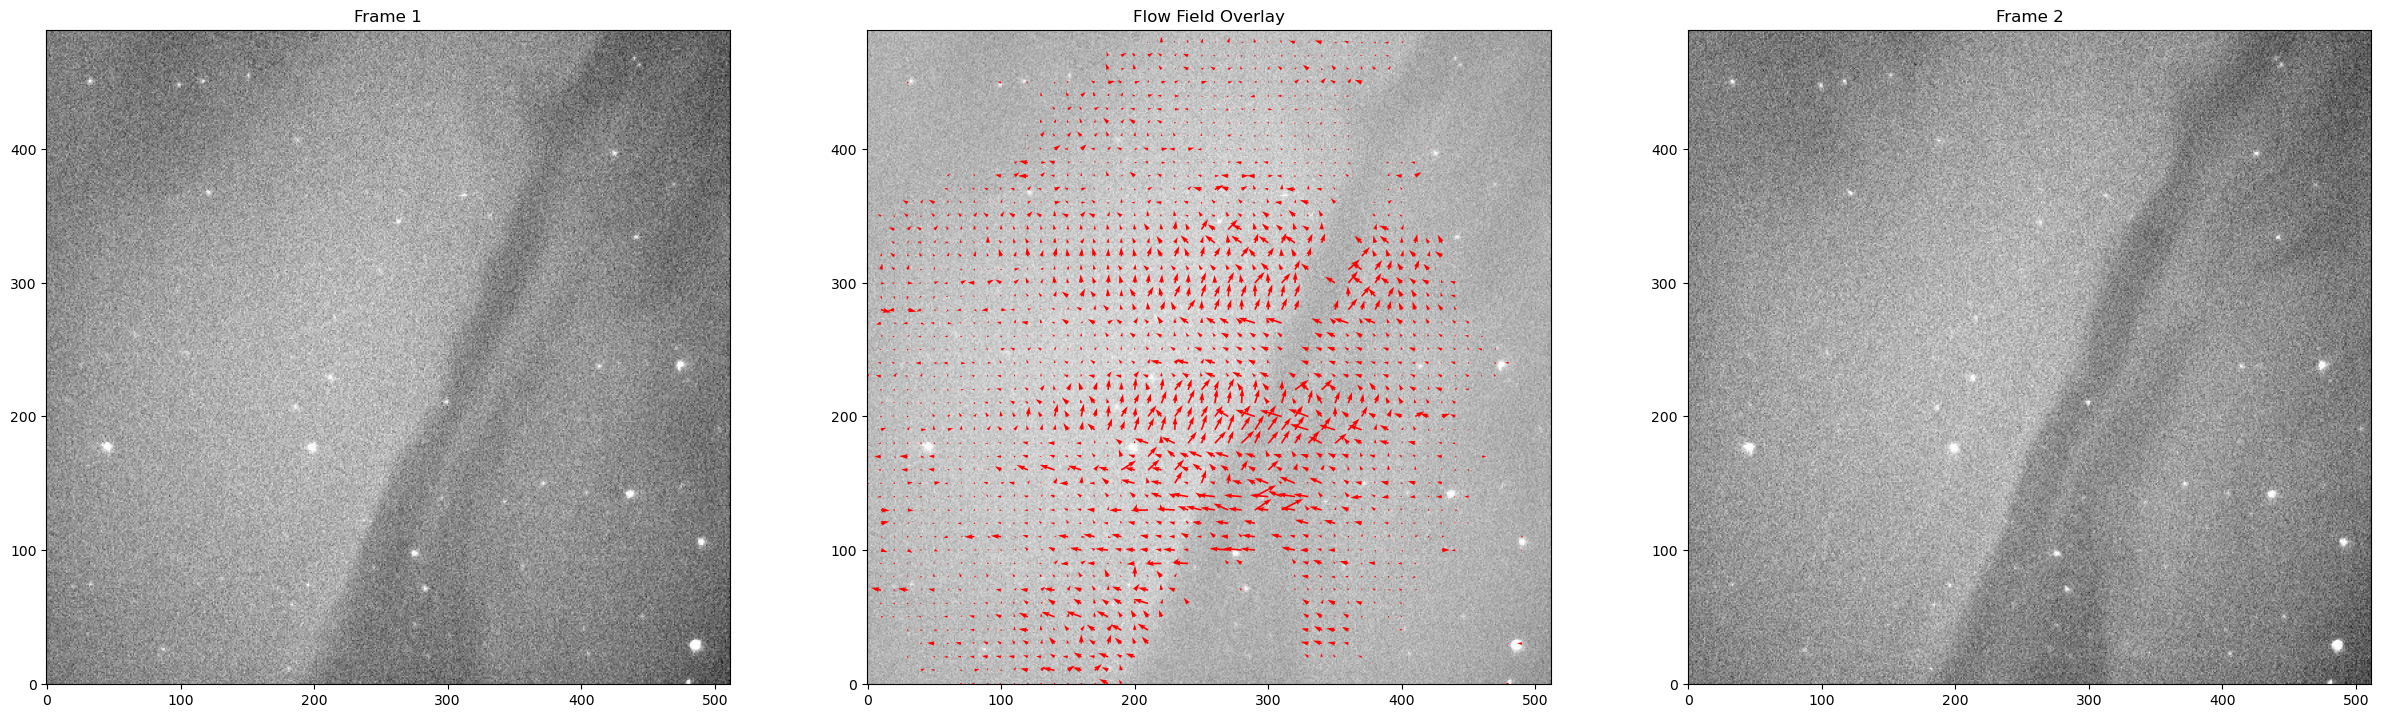

In [211]:
n = 2 # frame distance
frame1 = 3247
frame2 = frame1 + n
fn1 = f'/Users/michaellavender/Documents/BUSPC/optical flow/flct/frames/frame{frame1}.png'
fn2 =f'/Users/michaellavender/Documents/BUSPC/optical flow/flct/frames/frame{frame2}.png'
v = get_vels(fn1, fn2, deltat=2, deltas=1, sigma=8, thresh=0.7, biascor=False, interp=False)
display(fn1, fn2, v, scale=20)

In [ ]:
vel_list = []
fn_set = set()
start_frame = 3195
frame_gap = 4
end_frame = 3313
deltat = frame_gap * 1 # 1s per frame
base_fn = '/Users/michaellavender/Documents/BUSPC/optical flow/flct/frames/frame'

for f1, f2 in pairwise(tqdm(range(start_frame, end_frame + 1, frame_gap))):
    fn_set.update([f1, f2])
    fn1 = base_fn + str(f1) + '.png'
    fn2 = base_fn + str(f2) + '.png'
    v = get_vels(fn1, fn2, deltat=deltat, deltas=1, sigma=8, thresh=0.7, biascor=False, interp=False)
    vel_list.append(v)

vels = np.stack(vel_list, axis=0)

In [204]:
f_list = [base_fn + str(i) + '.png' for i in range(start_frame, end_frame + 1, frame_gap)]
a = animate(f_list, vels, scale=20, out='flct_out.mp4')